# LAB 4

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Project 1 add and estimate noise

read the image first.

Shape: (160, 200)
Data type: uint8
MAX value: 255
MIN value: 0


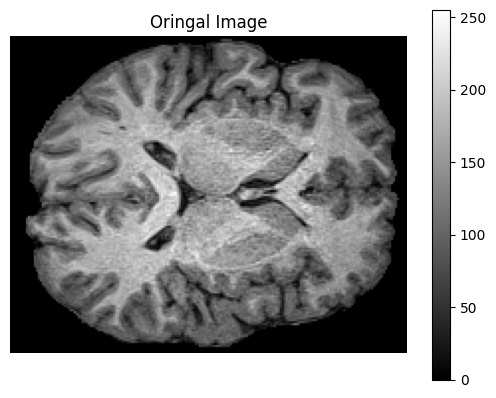

In [2]:
# open the iamge lab4-1.npy
original_img = np.load('./input/lab4-1.npy')

# show the infromation of the image
print("Shape:", original_img.shape)
print("Data type:", original_img.dtype)
print("MAX value:", original_img.max())
print("MIN value:", original_img.min())

# show the image
plt.imshow(original_img, cmap='gray')
plt.colorbar()
plt.title("Oringal Image")
plt.axis('off')
plt.show()

define a normalization funcion first, facilitates subsequent normalization.

Shape: (160, 200)
Data type: float64
MAX value: 1.0
MIN value: 0.0


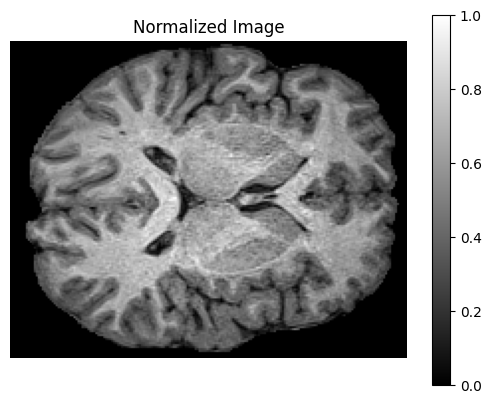

In [3]:
def imageNormalization(img, dtype: np.dtype = np.float64):
    # normalization the image to [0, 255]
    img_normalized = (img - img.min()) / (img.max() - img.min())
    return img_normalized.astype(dtype)

# test
normalized_img = imageNormalization(original_img)

# show the infromation of the image
print("Shape:", normalized_img.shape)
print("Data type:", normalized_img.dtype)
print("MAX value:", normalized_img.max())
print("MIN value:", normalized_img.min())

# show the image
plt.imshow(normalized_img, cmap='gray')
plt.colorbar()
plt.title("Normalized Image")
plt.axis('off')
plt.show()

### add Gaussian Noise and Salt-and-Pepper Noise.

Name: Add Gaussian Noise
Shape: (160, 200)
Data type: float64
MAX value: 255.1784241444683
MIN value: -0.5273724809035093

Name: Add Salt and Pepper Noise
Shape: (160, 200)
Data type: uint8
MAX value: 255
MIN value: 0


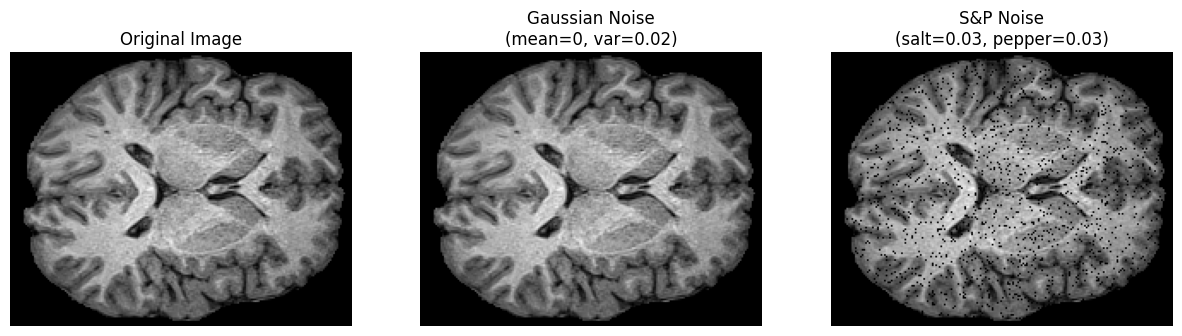

In [4]:
def addGaussianNoise(img, mean: float = 0, var: float = 0.01):
    """ add Gaussian noise to the image """
    sigma = np.sqrt(var)
    noise = np.random.normal(mean, sigma, img.shape)
    noisy_img = img + noise
    return noisy_img

def addSaltAndPepperNoise(img, salt_prob: float = 0.01, pepper_prob: float = 0.01):
    """ add salt and pepper noise to the image """
    noisy_img = img.copy()

    # calculate the number of salt and pepper noise
    num_salt = np.ceil(salt_prob * img.size)
    num_pepper = np.ceil(pepper_prob * img.size)

    # add salt noise
    salt_coords = [np.random.randint(0, i - 1, int(num_salt)) for i in img.shape]
    noisy_img[tuple(salt_coords)] = 1

    # add pepper noise
    pepper_coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in img.shape]
    noisy_img[tuple(pepper_coords)] = 0

    return noisy_img

# test
gauss_mean = 0
gauss_var = 0.02
img_add_gauss = addGaussianNoise(original_img, mean=gauss_mean, var=gauss_var)

sp_salt_p = 0.03
sp_pep_p = 0.03
img_add_sp = addSaltAndPepperNoise(original_img, salt_prob=sp_salt_p, pepper_prob=sp_pep_p)

# show the infromation of the image
print("Name: Add Gaussian Noise")
print("Shape:", img_add_gauss.shape)
print("Data type:", img_add_gauss.dtype)
print("MAX value:", img_add_gauss.max())
print("MIN value:", img_add_gauss.min())

print()
print("Name: Add Salt and Pepper Noise")
print("Shape:", img_add_sp.shape)
print("Data type:", img_add_sp.dtype)
print("MAX value:", img_add_sp.max())
print("MIN value:", img_add_sp.min())

# show the image
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(imageNormalization(original_img), cmap='gray')
axes[0].set_title('Original Image')
axes[1].imshow(imageNormalization(img_add_gauss), cmap='gray')
axes[1].set_title(f'Gaussian Noise\n(mean={gauss_mean}, var={gauss_var})')
axes[2].imshow(imageNormalization(img_add_sp), cmap='gray')
axes[2].set_title(f'S&P Noise\n(salt={sp_salt_p}, pepper={sp_pep_p})')
for ax in axes: 
    ax.axis('off')
plt.show()


Find SP Noise have no white pixel (no salt noise), update the function.

Name: Add Gaussian Noise
Shape: (160, 200)
Data type: float64
MAX value: 255.01895740250697
MIN value: -0.5753924094343923

Name: Add Salt and Pepper Noise
Shape: (160, 200)
Data type: float64
MAX value: 1.0
MIN value: 0.0


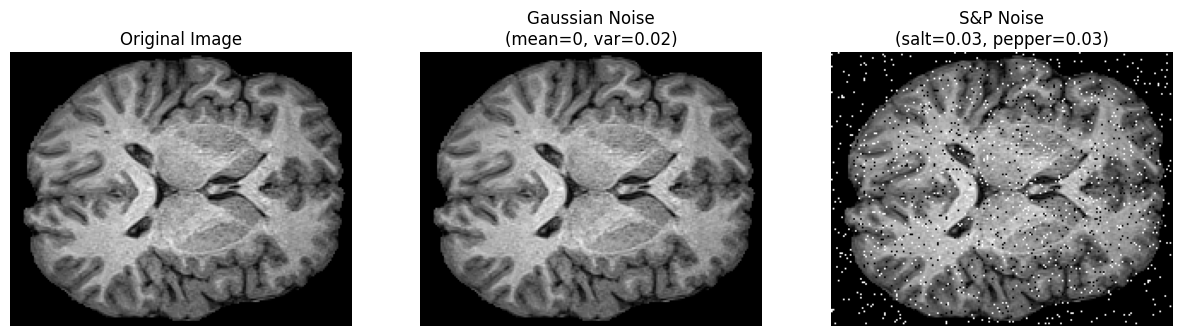

In [5]:
from email.mime import image

from numpy import maximum


def addGaussianNoise(img, mean: float = 0, var: float = 0.01, dtype: np.dtype = np.float64):
    """ add Gaussian noise to the image """
    sigma = np.sqrt(var)
    noise = np.random.normal(mean, sigma, img.shape)
    noisy_img = img + noise
    return noisy_img.astype(dtype)

def addSaltAndPepperNoise(img, salt_prob: float = 0.01, pepper_prob: float = 0.01, dtype: np.dtype = np.float64):
    """ add salt and pepper noise to the image """
    img = imageNormalization(img, dtype=dtype)
    noisy_img = img.copy()

    # calculate the number of salt and pepper noise
    num_salt = np.ceil(salt_prob * img.size)
    num_pepper = np.ceil(pepper_prob * img.size)

    # add salt noise
    salt_coords = [np.random.randint(0, i - 1, int(num_salt)) for i in img.shape]
    noisy_img[tuple(salt_coords)] = 1

    # add pepper noise
    pepper_coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in img.shape]
    noisy_img[tuple(pepper_coords)] = 0

    return noisy_img.astype(dtype)

# test
gauss_mean = 0
gauss_var = 0.02
img_add_gauss = addGaussianNoise(original_img, mean=gauss_mean, var=gauss_var)

sp_salt_p = 0.03
sp_pep_p = 0.03
img_add_sp = addSaltAndPepperNoise(original_img, salt_prob=sp_salt_p, pepper_prob=sp_pep_p)

# show the infromation of the image
print("Name: Add Gaussian Noise")
print("Shape:", img_add_gauss.shape)
print("Data type:", img_add_gauss.dtype)
print("MAX value:", img_add_gauss.max())
print("MIN value:", img_add_gauss.min())

print()
print("Name: Add Salt and Pepper Noise")
print("Shape:", img_add_sp.shape)
print("Data type:", img_add_sp.dtype)
print("MAX value:", img_add_sp.max())
print("MIN value:", img_add_sp.min())

# show the image
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(imageNormalization(original_img), cmap='gray')
axes[0].set_title('Original Image')
axes[1].imshow(imageNormalization(img_add_gauss), cmap='gray')
axes[1].set_title(f'Gaussian Noise\n(mean={gauss_mean}, var={gauss_var})')
axes[2].imshow(imageNormalization(img_add_sp), cmap='gray')
axes[2].set_title(f'S&P Noise\n(salt={sp_salt_p}, pepper={sp_pep_p})')
for ax in axes: 
    ax.axis('off')
plt.show()


### Estimate the parameters of noise model from the image.

Get the fucntion of get the histgram of image from lab2, and update it to suit for this lab.

TypeError: Invalid shape (256,) for image data

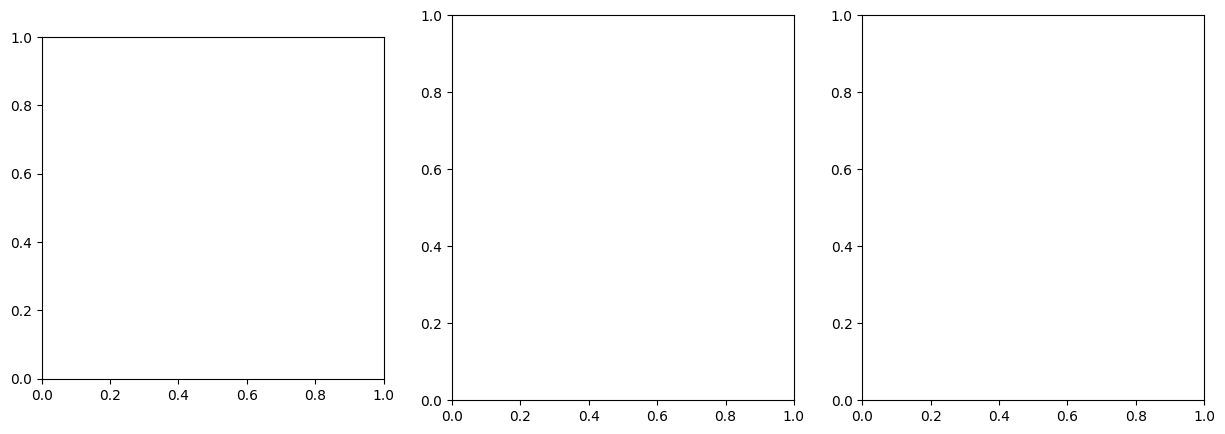

In [6]:
def quantify_histogram(img, dtype: np.dtype = np.float64):
    """
    quantify the image according to the histogram
    """

    # change the image to dtype
    image = img.astype(dtype)
    image_min = image.min()
    image_max = image.max()

    if image_max == image_min:
        output_image = np.zeros(256, dtype=dtype)
        output_image[0] = 1.0
        return output_image

    # normalize the image 
    image_norm = imageNormalization(image, dtype=dtype)
    image_quantized = np.clip((image_norm * 255).astype(np.int32), 0, 255)

    output_image = np.bincount(image_quantized.ravel(), minlength=256).astype(np.float32)
    output_image = output_image / output_image.sum()
    return output_image

# test
hist_original = quantify_histogram(original_img)
hist_gauss = quantify_histogram(img_add_gauss)
hist_sp = quantify_histogram(img_add_sp)

# bin
bins = np.arange(256)

# show the image
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(imageNormalization(hist_original), cmap='gray')
axes[0].set_title('Original Histogram')
axes[1].imshow(imageNormalization(hist_gauss), cmap='gray')
axes[1].set_title(f'Histogram of Gaussian Noise\n(mean={gauss_mean}, var={gauss_var})')
axes[2].imshow(imageNormalization(hist_sp), cmap='gray')
axes[2].set_title(f'Histogram of S&P Noise\n(salt={sp_salt_p}, pepper={sp_pep_p})')
for ax in axes: 
    ax.axis('off')
plt.show()

show Histogram should not use `plt.imshow()` but `plt.bar()`.

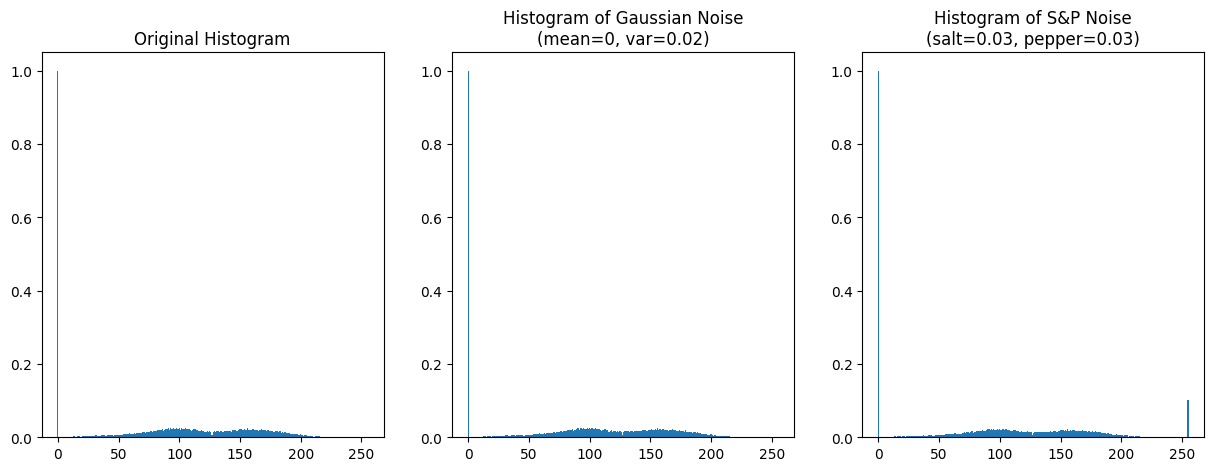

In [7]:
# show the image
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].bar(bins, imageNormalization(hist_original), width=1.0)
axes[0].set_title('Original Histogram')
axes[1].bar(bins, imageNormalization(hist_gauss), width=1.0)
axes[1].set_title(f'Histogram of Gaussian Noise\n(mean={gauss_mean}, var={gauss_var})')
axes[2].bar(bins, imageNormalization(hist_sp), width=1.0)
axes[2].set_title(f'Histogram of S&P Noise\n(salt={sp_salt_p}, pepper={sp_pep_p})')
plt.show()

should not normalize the histogram data.

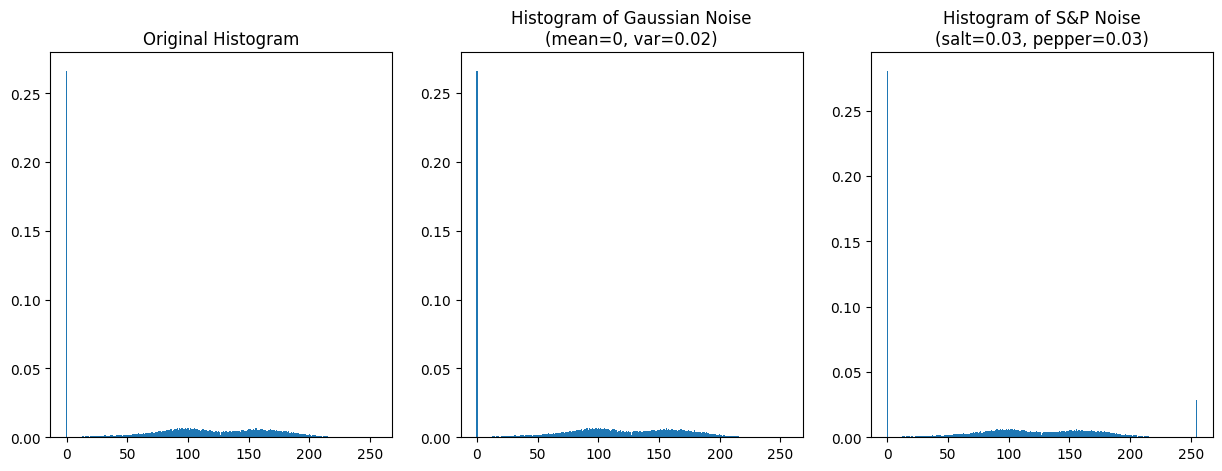

In [8]:
# show the image
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].bar(bins, hist_original, width=1.0)
axes[0].set_title('Original Histogram')
axes[1].bar(bins, hist_gauss, width=1.0)
axes[1].set_title(f'Histogram of Gaussian Noise\n(mean={gauss_mean}, var={gauss_var})')
axes[2].bar(bins, hist_sp, width=1.0)
axes[2].set_title(f'Histogram of S&P Noise\n(salt={sp_salt_p}, pepper={sp_pep_p})')
plt.show()

感觉加高斯噪声的时候参数给的太小了，看不出变化。加一个大一点的高斯噪声，并且联合展示。

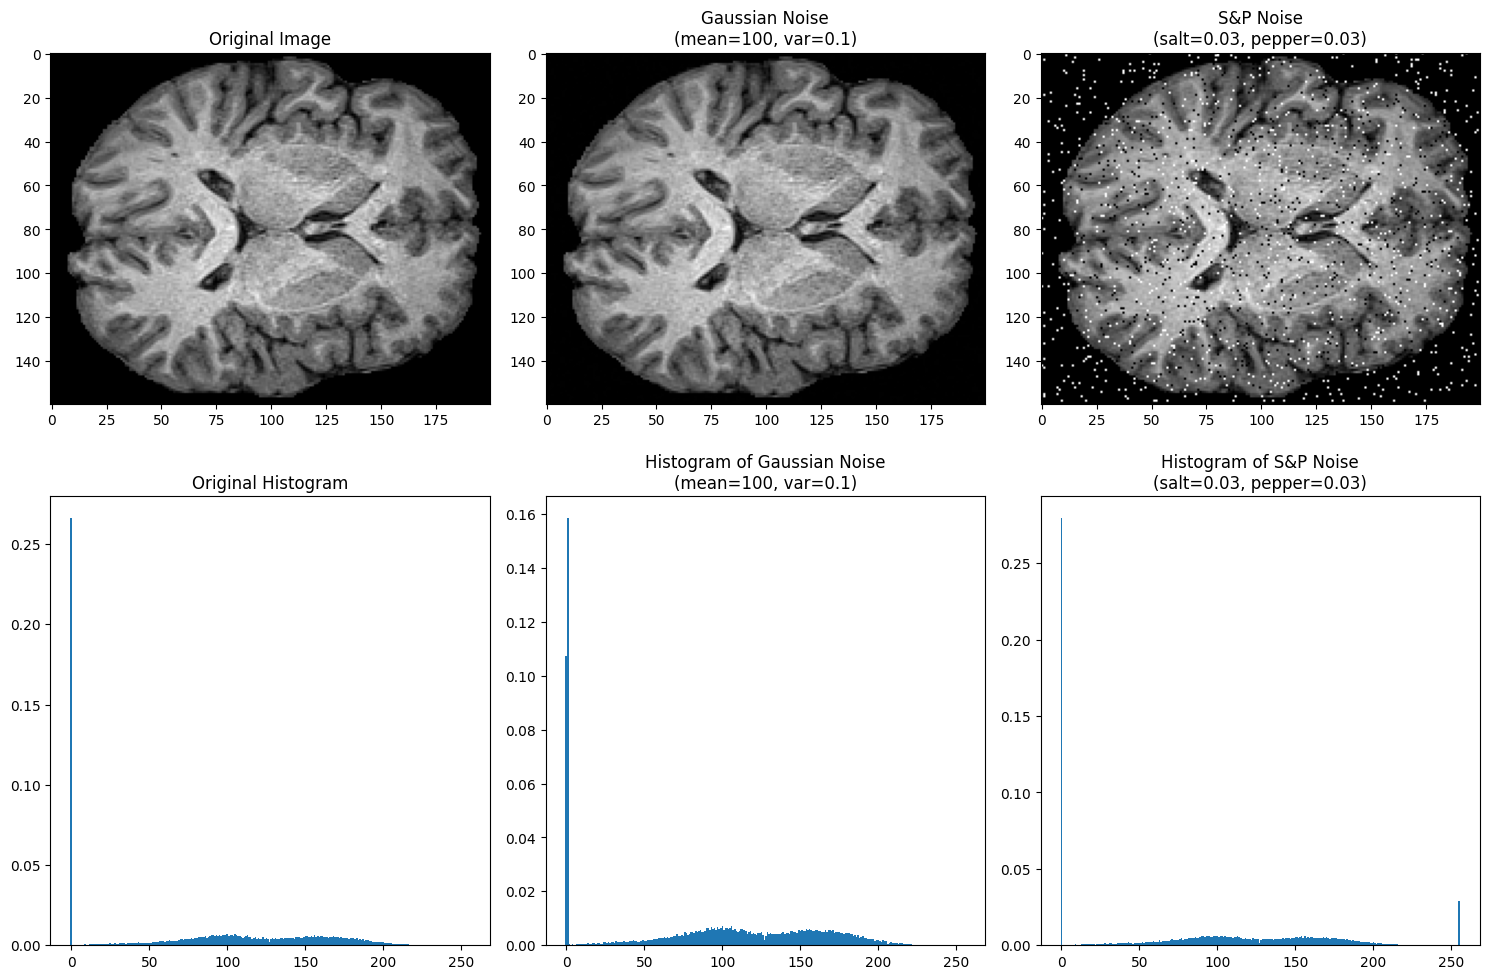

In [9]:
# Add Noise
gauss_mean = 100
gauss_var = 0.1
img_add_gauss = addGaussianNoise(original_img, mean=gauss_mean, var=gauss_var)
hist_gauss = quantify_histogram(img_add_gauss)

sp_salt_p = 0.03
sp_pep_p = 0.03
img_add_sp = addSaltAndPepperNoise(original_img, salt_prob=sp_salt_p, pepper_prob=sp_pep_p)
hist_sp = quantify_histogram(img_add_sp)

# show the image
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(imageNormalization(original_img), cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 1].imshow(imageNormalization(img_add_gauss), cmap='gray')
axes[0, 1].set_title(f'Gaussian Noise\n(mean={gauss_mean}, var={gauss_var})')
axes[0, 2].imshow(imageNormalization(img_add_sp), cmap='gray')
axes[0, 2].set_title(f'S&P Noise\n(salt={sp_salt_p}, pepper={sp_pep_p})')
axes[1, 0].bar(bins, hist_original, width=1.0)
axes[1, 0].set_title('Original Histogram')
axes[1, 1].bar(bins, hist_gauss, width=1.0)
axes[1, 1].set_title(f'Histogram of Gaussian Noise\n(mean={gauss_mean}, var={gauss_var})')
axes[1, 2].bar(bins, hist_sp, width=1.0)
axes[1, 2].set_title(f'Histogram of S&P Noise\n(salt={sp_salt_p}, pepper={sp_pep_p})')
plt.tight_layout()
plt.show()


噪声都挺明显的，开始估计。

#### Estimate Gaussian Noise

In [ ]:
def estimateGaussianNoise(img_clean, img_noisy, dtype: np.dtype = np.float64):
    """ estimate Gaussian Noise """
    # calculate the noise
    noise = img_noisy - img_clean

    # calculate the mean and variance of the noise
    mean = np.mean(noise)
    var = np.var(noise)

    return mean, var

# test 
estimated_mean_gauss, estimated_var_gauss = estimateGaussianNoise(original_img, img_add_gauss)
print(f"Estimated Gaussian Noise - Mean: {estimated_mean_gauss:.4f}, Variance: {estimated_var_gauss:.4f}")

Estimated Gaussian Noise - Mean: 99.9950, Variance: 0.0990


The estimated results are very close to the actual values.

#### Estimate Salt-and-Pepper Noise

In [11]:
def estimateSPNoise(img_clean, img_noisy, dtype: np.dtype = np.float64):
    """ estimate Salt and Pepper Noise """
    # calculate the noise
    img_clean_norm = imageNormalization(img_clean, dtype=dtype)
    img_noisy_norm = imageNormalization(img_noisy, dtype=dtype)

    # calculate the salt and pepper noise mask
    changed = img_clean_norm != img_noisy_norm
    salt_mask = changed & (img_noisy_norm == 1)
    pepper_mask = changed & (img_noisy_norm == 0)
    total = img_clean.size

    # calculate the salt and pepper noise probability
    salt_prob = np.sum(salt_mask) / total
    pepper_prob = np.sum(pepper_mask) / total

    return salt_prob, pepper_prob

# test 
estimated_salt_prob, estimated_pepper_prob = estimateSPNoise(original_img, img_add_sp)
print(f"Estimated S&P Noise - Salt Probability: {estimated_salt_prob:.4f}, Pepper Probability: {estimated_pepper_prob:.4f}")

Estimated S&P Noise - Salt Probability: 0.0290, Pepper Probability: 0.0219


Theoretically, the estimation algorithm for salt-and-pepper noise is entirely correct. 

However, when add salt-and-pepper noise, some pixels are `0` or `256` already, so they are not noise just based on the result.

Therefore, the estimate value will smaller than the actual value.

### Denoise

First, write some evaluation functions to assess the denoising results.

Have finish function `quantify_histogram()`, still cpoy the function `quantify_psnr()` from lab2.

In [12]:
# quantify: histogram
def quantify_histogram(img, dtype: np.dtype = np.float64):
    """
    quantify the image according to the histogram
    """

    # change the image to dtype
    img = img.astype(dtype)
    image_min = img.min()
    image_max = img.max()

    if image_max == image_min:
        output_image = np.zeros(256, dtype=dtype)
        output_image[0] = 1.0
        return output_image

    # normalize the image 
    image_norm = imageNormalization(img, dtype=dtype)
    image_quantized = np.clip((image_norm * 255).astype(np.int32), 0, 255)

    output_image = np.bincount(image_quantized.ravel(), minlength=256).astype(np.float32)
    output_image = output_image / output_image.sum()
    return output_image

# quantify: psnr
def quantify_psnr(img_original, img_fixed, max_pixel: float = 255.0, dtype: np.dtype = np.float64):
    """ quantify the image quality using PSNR """
    # calculate the mean squared error
    mse = np.mean((img_original.astype(dtype) - img_fixed.astype(dtype)) ** 2)

    if mse == 0:
        return np.inf

    # calculate the PSNR
    psnr = 10 * np.log10((max_pixel ** 2) / mse)
    return psnr

# test 
psnr_gauss = quantify_psnr(original_img, img_add_gauss)
psnr_sp = quantify_psnr(original_img, img_add_sp)
print(f"PSNR of Gaussian Noise Image: {psnr_gauss:.4f} dB")
print(f"PSNR of S&P Noise Image: {psnr_sp:.4f} dB")


PSNR of Gaussian Noise Image: 8.1312 dB
PSNR of S&P Noise Image: 7.1990 dB


now denoise the image.

#### Denoise Gaussian Noise

PSNR of Denoised Gaussian Noise Image: 27.8633 dB


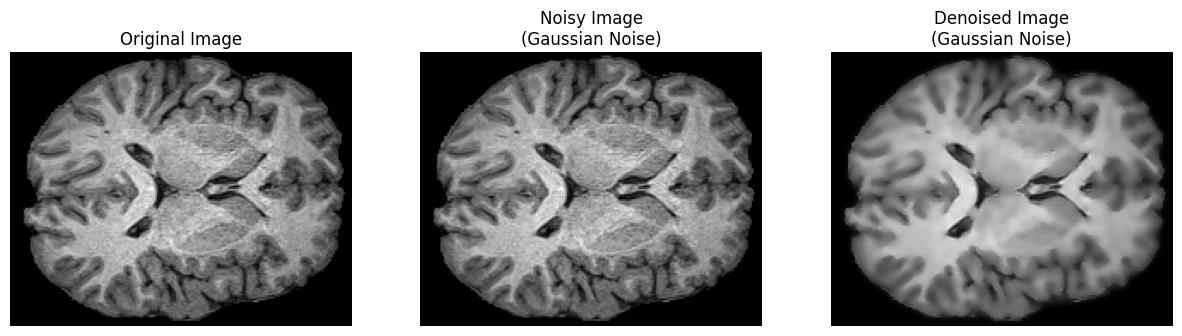

In [15]:
from scipy.signal import wiener

def denoiseGaussianNoise(img_noisy, mean: float = 0, var: float = 0.01, kernel_size: int = 3, dtype: np.dtype = np.float64):
    """ denoise Gaussian Noise using a simple mean filter """
    corrected = img_noisy.astype(np.float32) - mean
    corrected = np.clip(corrected, 0, 255)
    denoised = wiener(corrected, (kernel_size, kernel_size))
    return denoised.astype(dtype)

# test 
denoised_gauss = denoiseGaussianNoise(img_add_gauss, mean=estimated_mean_gauss, var=estimated_var_gauss, kernel_size=5)
hist_gauss_denoised = quantify_histogram(denoised_gauss)
psnr_denoised_gauss = quantify_psnr(original_img, denoised_gauss)
print(f"PSNR of Denoised Gaussian Noise Image: {psnr_denoised_gauss:.4f} dB")

# show the image
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(imageNormalization(original_img), cmap='gray')
axes[0].set_title('Original Image')
axes[1].imshow(imageNormalization(img_add_gauss), cmap='gray')
axes[1].set_title('Noisy Image\n(Gaussian Noise)')
axes[2].imshow(imageNormalization(denoised_gauss), cmap='gray')
axes[2].set_title('Denoised Image\n(Gaussian Noise)')
for ax in axes: 
    ax.axis('off')
plt.show()

    

明显平滑过渡了。。。

尝试选取更小的 `kernel_size`.

/mnt/d/AppData/Python/BIP/.venv/lib/python3.13/site-packages/scipy/signal/_signaltools.py:1728: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
/mnt/d/AppData/Python/BIP/.venv/lib/python3.13/site-packages/scipy/signal/_signaltools.py:1728: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)


PSNR of Denoised Gaussian Noise Image: 30.6584 dB


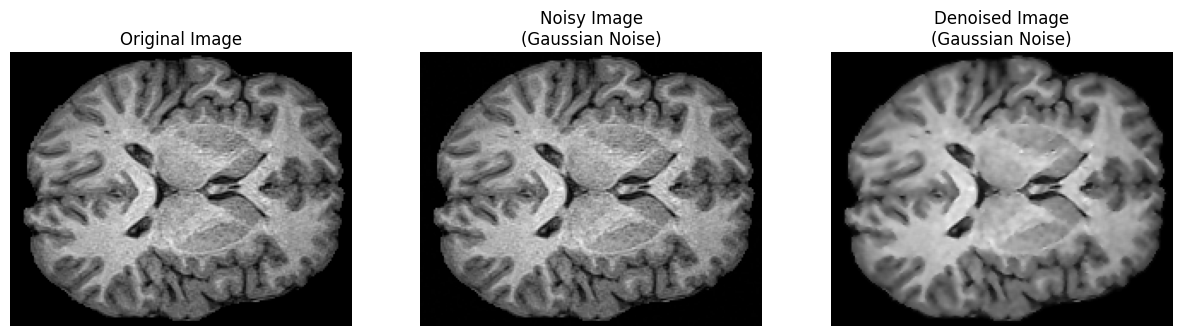

In [16]:
# test 
denoised_gauss = denoiseGaussianNoise(img_add_gauss, mean=estimated_mean_gauss, var=estimated_var_gauss, kernel_size=3)
hist_gauss_denoised = quantify_histogram(denoised_gauss)
psnr_denoised_gauss = quantify_psnr(original_img, denoised_gauss)
print(f"PSNR of Denoised Gaussian Noise Image: {psnr_denoised_gauss:.4f} dB")

# show the image
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(imageNormalization(original_img), cmap='gray')
axes[0].set_title('Original Image')
axes[1].imshow(imageNormalization(img_add_gauss), cmap='gray')
axes[1].set_title('Noisy Image\n(Gaussian Noise)')
axes[2].imshow(imageNormalization(denoised_gauss), cmap='gray')
axes[2].set_title('Denoised Image\n(Gaussian Noise)')
for ax in axes: 
    ax.axis('off')
plt.show()

效果好了很多

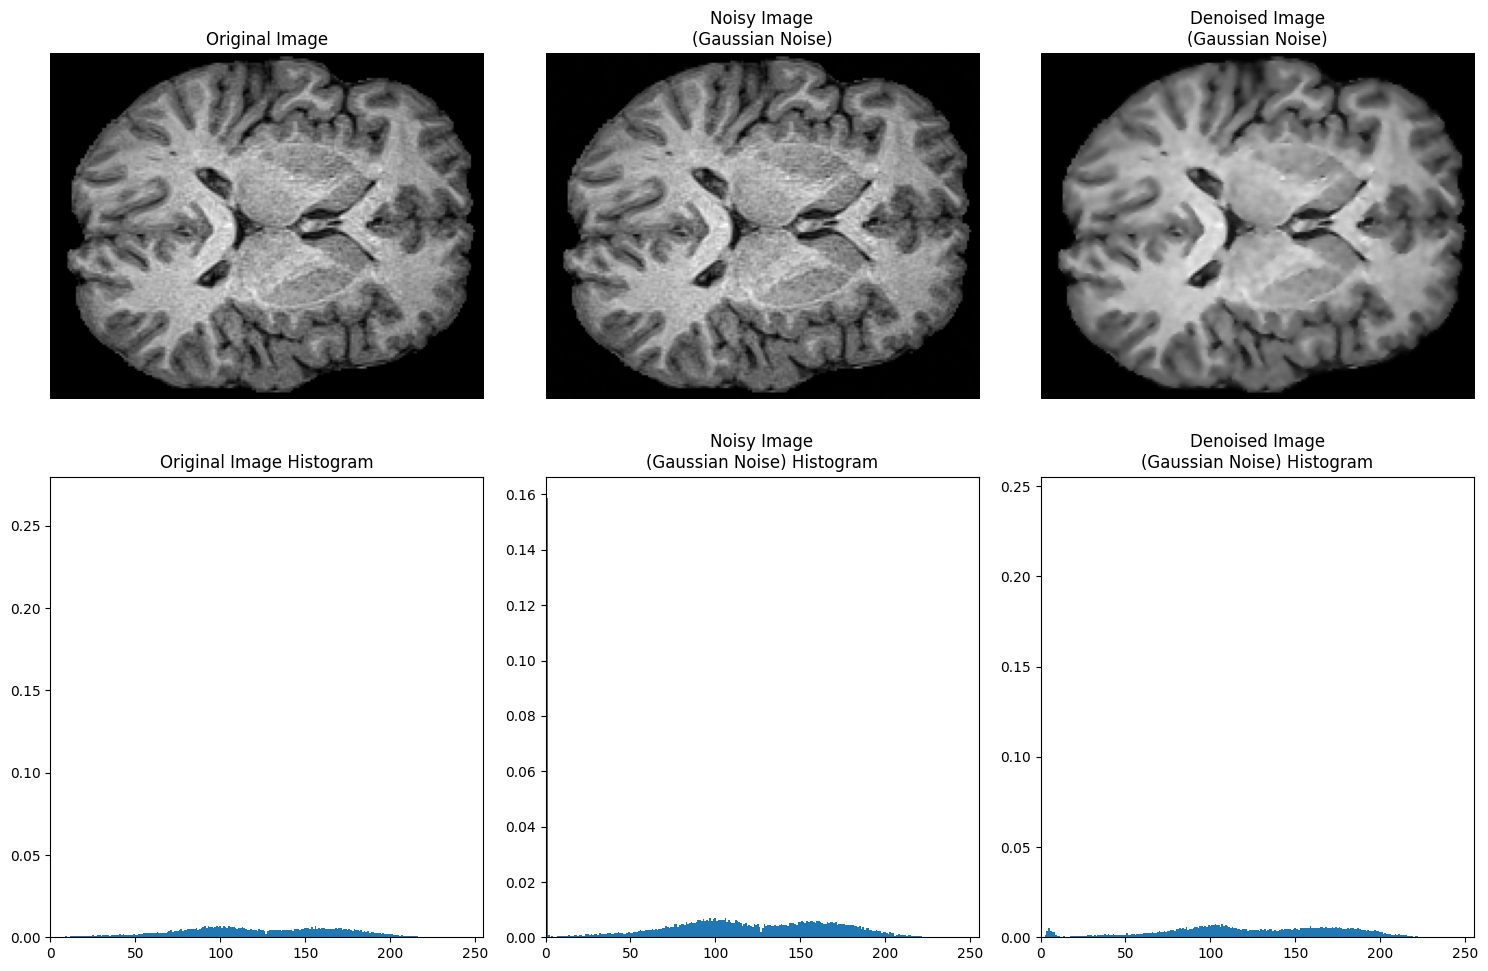

In [18]:
def show_images(images, titles, figsize=(15, 5), cmap='gray'):
    """ show images in a row """
    fig, axes = plt.subplots(2, len(images), figsize=(5 * len(images), 10))
    bins = np.arange(256)
    for i, (img, title) in enumerate(zip(images, titles)):
        # first row: images
        axes[0, i].imshow(imageNormalization(img), cmap=cmap)
        axes[0, i].set_title(title)
        axes[0, i].axis('off')

        # second row: histograms
        images_hist = quantify_histogram(img)
        axes[1, i].bar(bins, images_hist, width=1.0)
        axes[1, i].set_title(f'{title} Histogram')
        axes[1, i].set_xlim(0, 255)

    plt.tight_layout()
    plt.show()

# test
show_images(
    images=[original_img, img_add_gauss, denoised_gauss],
    titles=['Original Image', 'Noisy Image\n(Gaussian Noise)', 'Denoised Image\n(Gaussian Noise)']
)

从直方图来看，去噪效果也不错。

#### Denoise Salt-and-Pepper Noise

PSNR of Denoised S&P Noise Image: 7.1989 dB


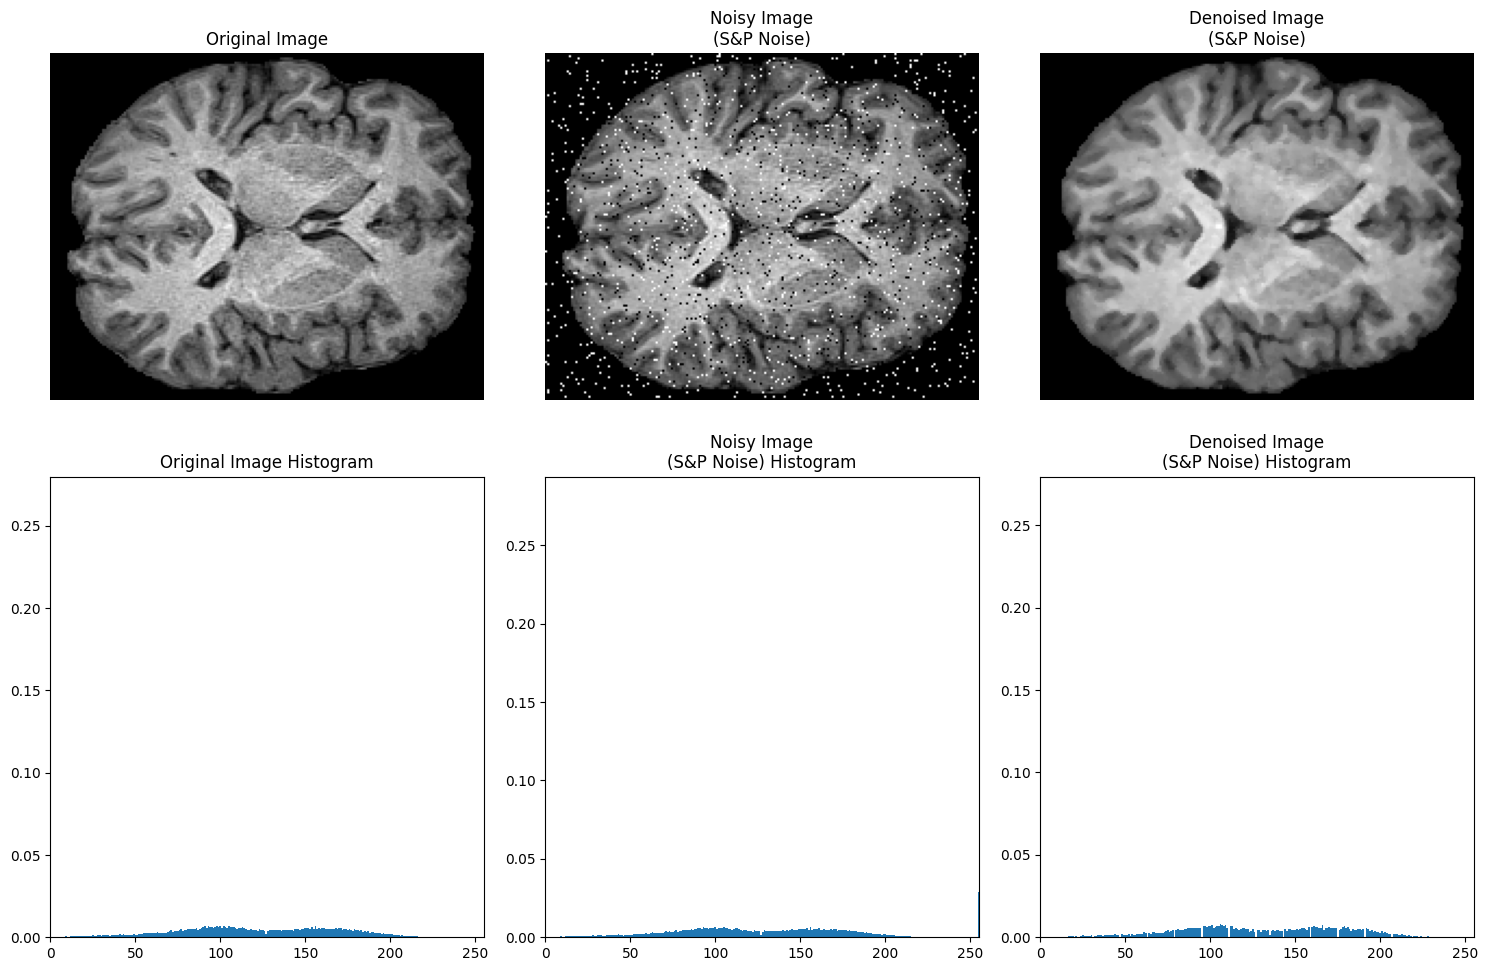

In [19]:
from scipy.ndimage import median_filter


def denoiseSPNoise(img_noisy, salt_prob: float = 0.01, pepper_prob: float = 0.01, kernel_size: int = None, dtype: np.dtype = np.float64):
    """ denoise Salt and Pepper Noise using a median filter """
    total_prob = salt_prob + pepper_prob
    
    if kernel_size:
        denoised = median_filter(img_noisy, size=kernel_size)
    else:
        if total_prob < 0.03:
            denoised = median_filter(img_noisy, size=3)
        elif total_prob < 0.08:
            denoised = median_filter(img_noisy, size=5)
        else:
            denoised = median_filter(img_noisy, size=7)

    return denoised.astype(dtype)

# test
denoised_sp = denoiseSPNoise(img_add_sp, salt_prob=estimated_salt_prob, pepper_prob=estimated_pepper_prob, kernel_size=3)
hist_sp_denoised = quantify_histogram(denoised_sp)
psnr_denoised_sp = quantify_psnr(original_img, denoised_sp)
print(f"PSNR of Denoised S&P Noise Image: {psnr_denoised_sp:.4f} dB")

# show the image
show_images(
    images=[original_img, img_add_sp, denoised_sp],
    titles=['Original Image', 'Noisy Image\n(S&P Noise)', 'Denoised Image\n(S&P Noise)']
)  

## Project 2 morphological operations

read images first.

Brain Mask - Shape: (528, 768) Data type: bool MAX value: True MIN value: False
Tissue Mask - Shape: (528, 768) Data type: float32 MAX value: 1.0 MIN value: 0.0
Brain Slice - Shape: (528, 768) Data type: float32 MAX value: 1386.0011 MIN value: 0.0
Tissue Slice - Shape: (528, 768) Data type: float32 MAX value: 773.9954 MIN value: 0.0


TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

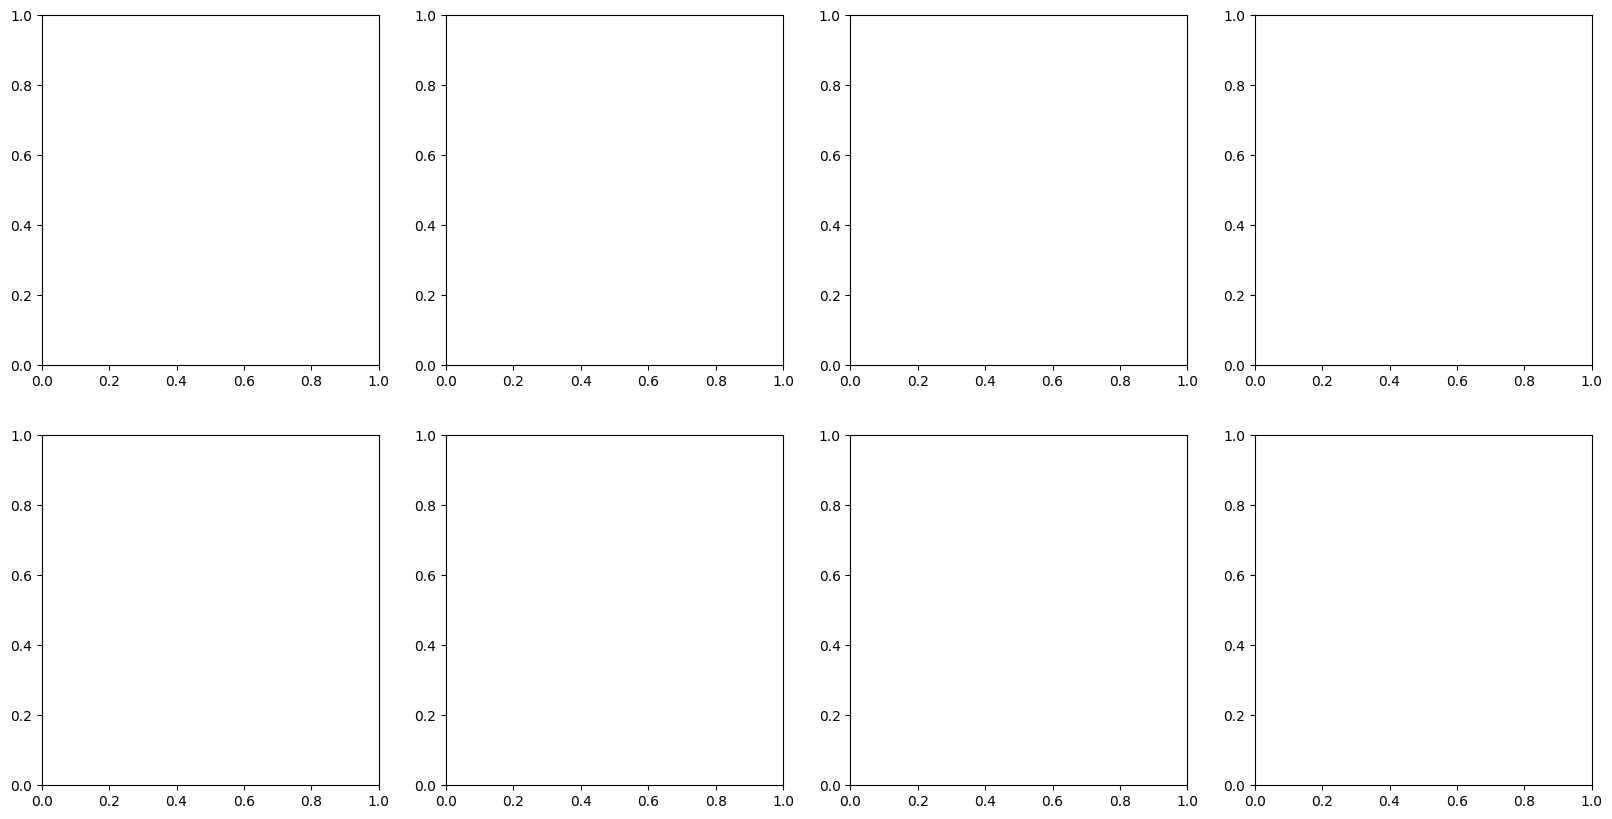

In [22]:
# open the image
brain_mask = np.load("./input/lab4-2/noisy_brain_mask.npy")
tissue_mask = np.load("./input/lab4-2/brain_tissue_mask_slice.npy")
brain_slice = np.load("./input/lab4-2/original_brain_slice_.npy")
tissue_slice = np.load("./input/lab4-2/brain_tissue_slice.npy")

# show the infromation of the image
print("Brain Mask - Shape:", brain_mask.shape, "Data type:", brain_mask.dtype, "MAX value:", brain_mask.max(), "MIN value:", brain_mask.min())
print("Tissue Mask - Shape:", tissue_mask.shape, "Data type:", tissue_mask.dtype, "MAX value:", tissue_mask.max(), "MIN value:", tissue_mask.min())
print("Brain Slice - Shape:", brain_slice.shape, "Data type:", brain_slice.dtype, "MAX value:", brain_slice.max(), "MIN value:", brain_slice.min())
print("Tissue Slice - Shape:", tissue_slice.shape, "Data type:", tissue_slice.dtype, "MAX value:", tissue_slice.max(), "MIN value:", tissue_slice.min())

# show the image
show_images(
    images=[brain_mask, tissue_mask, brain_slice, tissue_slice],
    titles=['Brain Mask', 'Tissue Mask', 'Brain Slice', 'Tissue Slice']
)

For Project 2, define a new show image function without normalization.

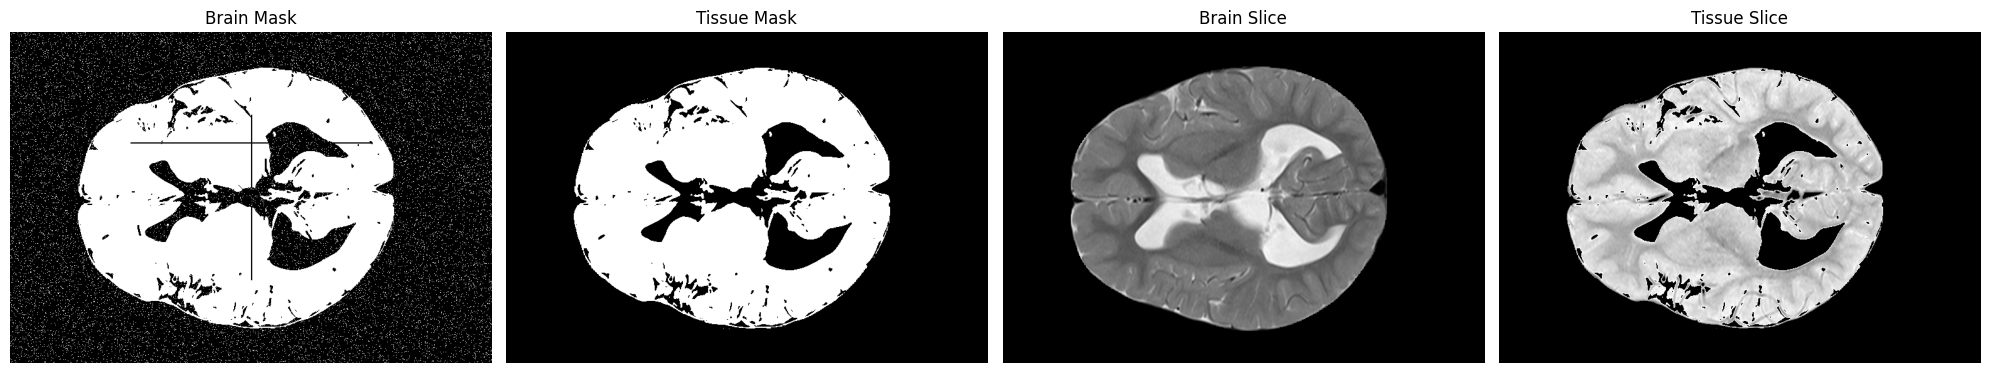

In [23]:
def show_images_project2(images, titles, cmap='gray'):
    """ show images in a row """
    n = len(images)
    plt.figure(figsize=(n * 5, 5))
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(1, n, i)
        plt.imshow(img, cmap=cmap)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# test
show_images_project2(
    images=[brain_mask, tissue_mask, brain_slice, tissue_slice],
    titles=['Brain Mask', 'Tissue Mask', 'Brain Slice', 'Tissue Slice']
)

We can see that `Brain Mask` have many noise:

- background have many white pixels
- in the brain have two black lines

For background:
- just small `erosion` is enough

For two line:
- use suitable `dilation`.

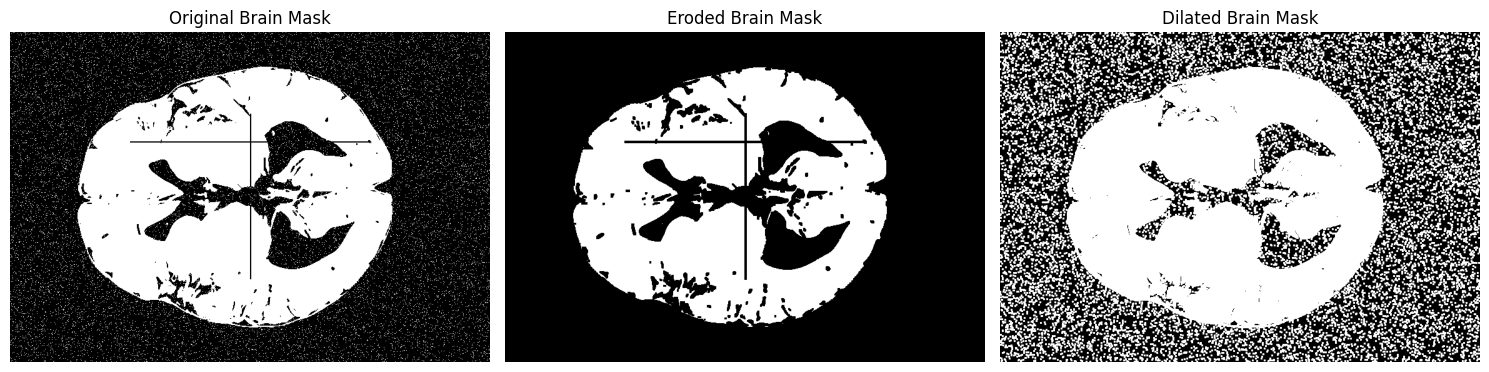

In [24]:
def binaryErosion(img, kernel_size: int = 3, dtype: np.dtype = np.bool):
    """ binary erosion """
    img = img.astype(dtype)
    eroded = np.copy(img)
    pad_size = kernel_size // 2
    padded_img = np.pad(img, pad_size, mode='constant', constant_values=0)
    
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded_img[i:i+kernel_size, j:j+kernel_size]
            if np.all(region == 1):
                eroded[i, j] = 1
            else:
                eroded[i, j] = 0

    return eroded.astype(dtype)

def binaryDilation(img, kernel_size: int = 3, dtype: np.dtype = np.bool):
    """ binary dilation """
    img = img.astype(dtype)
    dilated = np.copy(img)
    pad_size = kernel_size // 2
    padded_img = np.pad(img, pad_size, mode='constant', constant_values=0)
    
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded_img[i:i+kernel_size, j:j+kernel_size]
            if np.any(region == 1):
                dilated[i, j] = 1
            else:
                dilated[i, j] = 0

    return dilated.astype(dtype)

# test
eroded_brain_mask = binaryErosion(brain_mask, kernel_size=3)
dilated_brain_mask = binaryDilation(brain_mask, kernel_size=3)

# show the image
show_images_project2(
    images=[brain_mask, eroded_brain_mask, dilated_brain_mask],
    titles=['Original Brain Mask', 'Eroded Brain Mask', 'Dilated Brain Mask']
)

两个函数都很成功。

同时，从实验的结果来看，背景中的噪点很多，先采用 `Erosion` 再 `Dilate` 才是合理的顺序。

### Apply morphological operations to the noisy_brain_mask.npy to denoise, remove wrong segment boundary and fill partial internal holes.

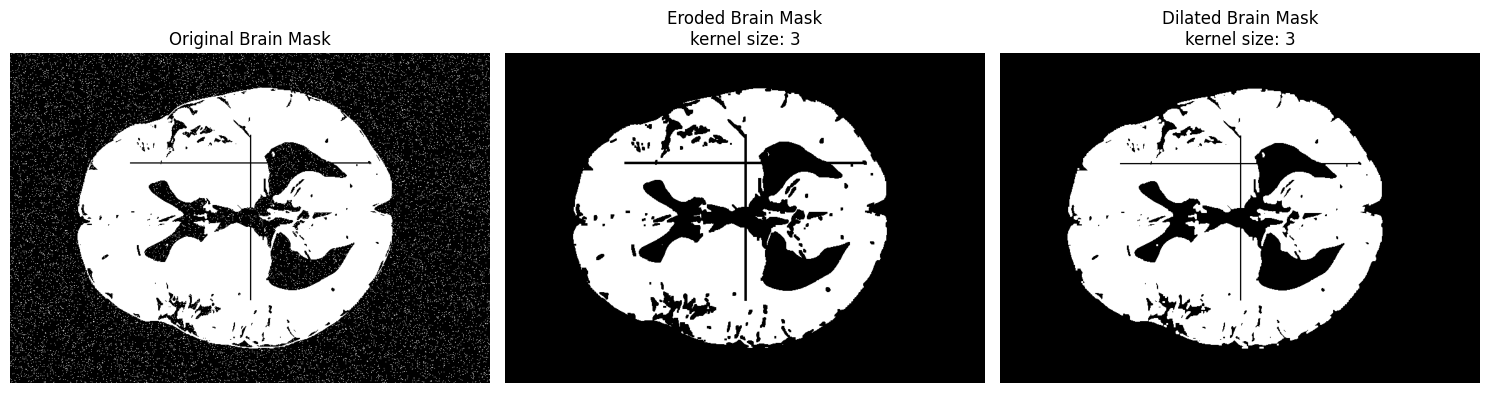

In [25]:
# erosion first
erosion_kernel_size = 3
eroded_brain_mask = binaryErosion(brain_mask, kernel_size=erosion_kernel_size)

# dilation second
dilation_kernel_size = 3
dilated_brain_mask = binaryDilation(eroded_brain_mask, kernel_size=dilation_kernel_size)

# show the image
show_images_project2(
    images=[brain_mask, eroded_brain_mask, dilated_brain_mask],
    titles=[
        'Original Brain Mask', 
        f'Eroded Brain Mask\nkernel size: {erosion_kernel_size}', 
        f'Dilated Brain Mask\nkernel size: {dilation_kernel_size}'
    ]
)

根据输出图像，可以看到：`Erosion` 的大小已经完全足够了，`Dilate` 的大小还有点不足，在大脑内部的黑线没有去除完全，需要增大 `dilation_kernel_size`.

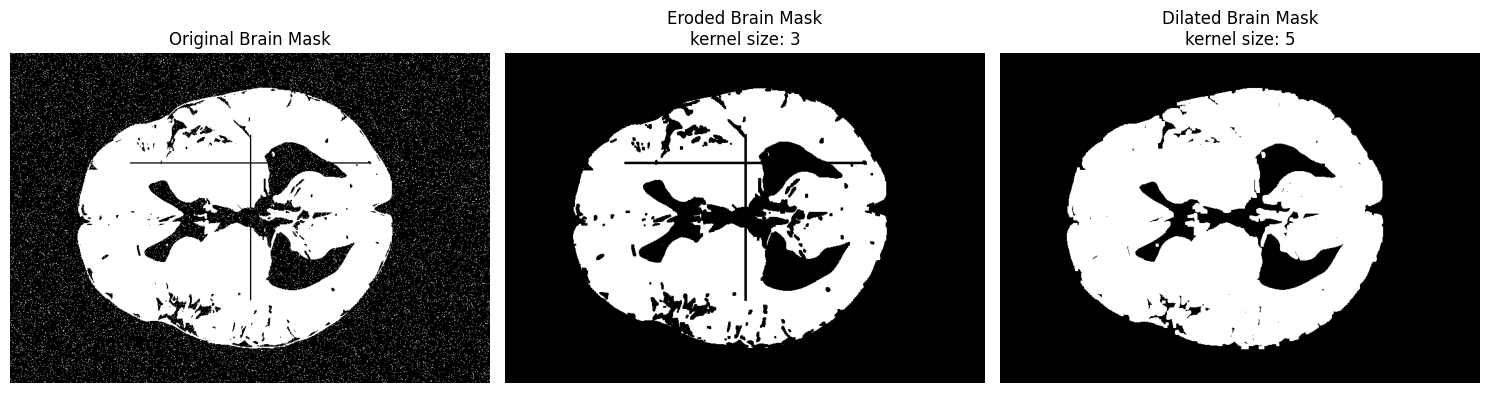

In [31]:
# erosion first
erosion_kernel_size = 3
eroded_brain_mask = binaryErosion(brain_mask, kernel_size=erosion_kernel_size)

# dilation second
dilation_kernel_size = 5
dilated_brain_mask = binaryDilation(eroded_brain_mask, kernel_size=dilation_kernel_size)

# show the image
show_images_project2(
    images=[brain_mask, eroded_brain_mask, dilated_brain_mask],
    titles=[
        'Original Brain Mask', 
        f'Eroded Brain Mask\nkernel size: {erosion_kernel_size}', 
        f'Dilated Brain Mask\nkernel size: {dilation_kernel_size}'
    ]
)

两条黑线已经完全消失了，但是脑组织内部还是有很多小缺陷，需要用更大的 `dilation_kernel_size`. 同时，在 Dilate 之后还可以再 Erosion 一下，把多的部分腐蚀掉。

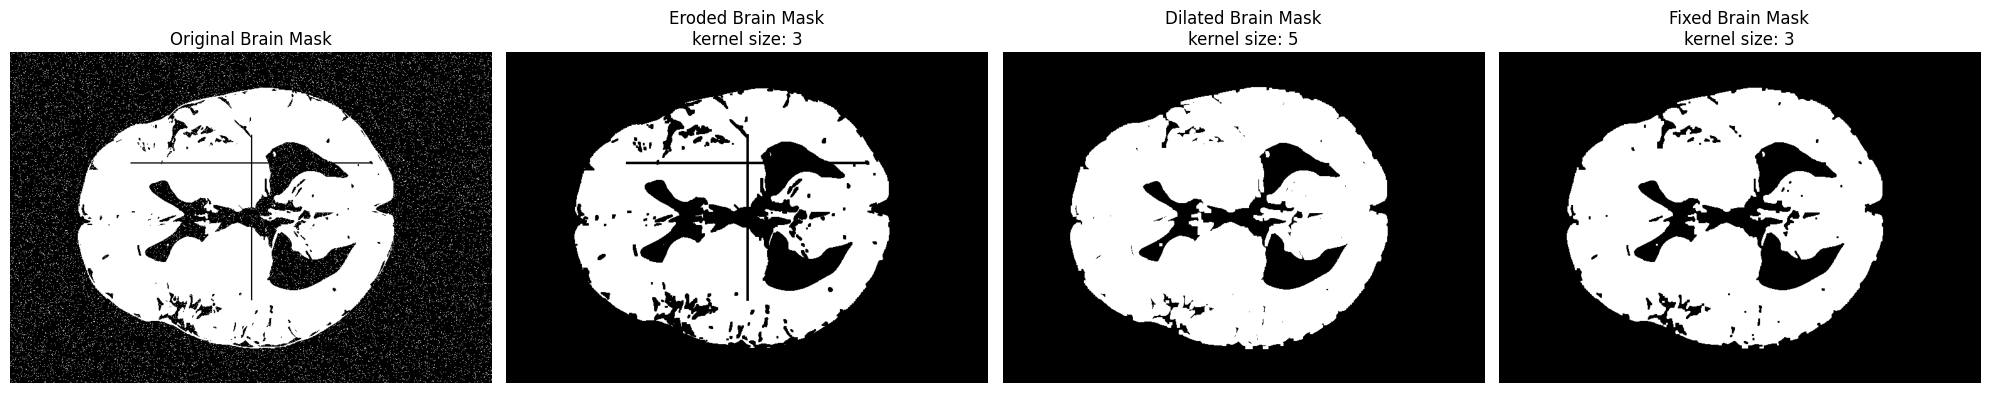

In [33]:
# erosion first
erosion_kernel_size = 3
eroded_brain_mask = binaryErosion(brain_mask, kernel_size=erosion_kernel_size)

# dilation second
dilation_kernel_size = 5
dilated_brain_mask = binaryDilation(eroded_brain_mask, kernel_size=dilation_kernel_size)

back_kernel_size = dilation_kernel_size - erosion_kernel_size + 1
fixed_brain_mask = binaryErosion(dilated_brain_mask, kernel_size=back_kernel_size)

# show the image
show_images_project2(
    images=[brain_mask, eroded_brain_mask, dilated_brain_mask, fixed_brain_mask],
    titles=[
        'Original Brain Mask', 
        f'Eroded Brain Mask\nkernel size: {erosion_kernel_size}', 
        f'Dilated Brain Mask\nkernel size: {dilation_kernel_size}',
        f'Fixed Brain Mask\nkernel size: {back_kernel_size}'
    ]
)

### Compaerd with the given brain mask

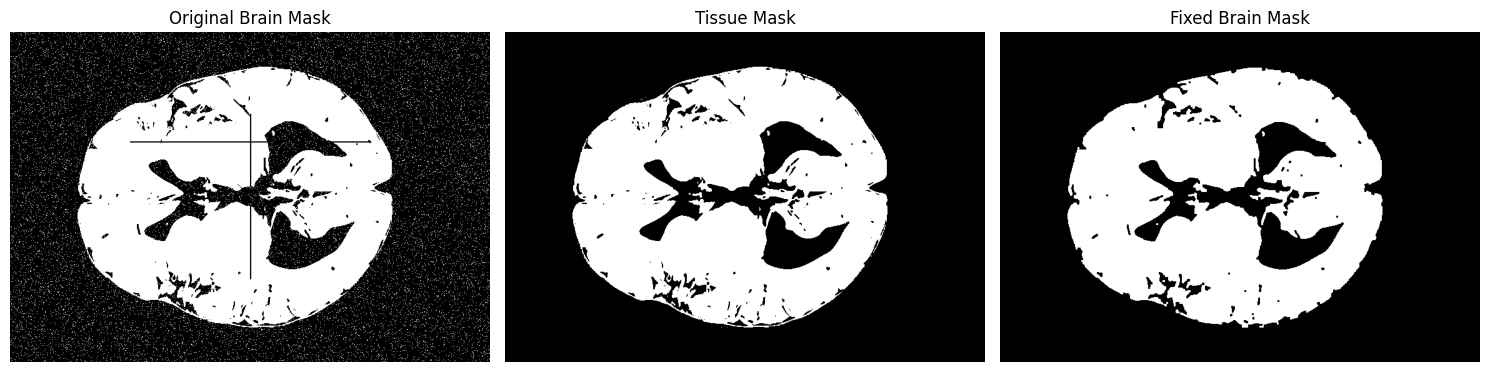

In [34]:
# compare with the brain_mask and tissue_mask
show_images_project2(
    images=[brain_mask, tissue_mask, fixed_brain_mask],
    titles=['Original Brain Mask', 'Tissue Mask', 'Fixed Brain Mask']
)

为了更好对比图像，编写一个掩膜函数。

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


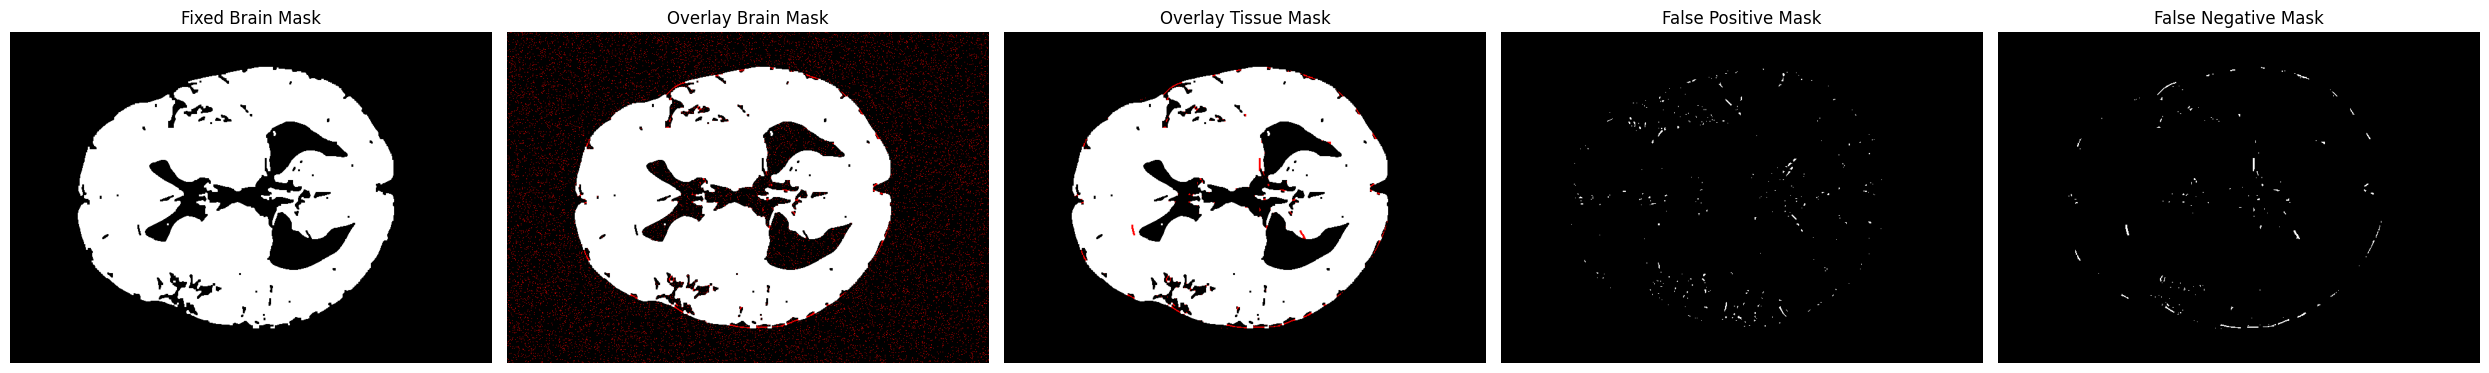

In [41]:
def overlayMask(img_background, img_mask, color: tuple = (255, 0, 0), alpha: float = 0.5, dtype: np.dtype = np.float64):
    """ overlay the mask on the background image """
    background = np.asarray(img_background, dtype=dtype)
    mask = np.asarray(img_mask, dtype=dtype)

    if background.ndim == 2:
        background = imageNormalization(background, dtype=dtype)
        background_rgb = np.stack([background, background, background], axis=-1)
    else:
        if background.max() > 1.0:
            background = background / 255.0
        background_rgb = np.clip(background, 0, 1)
    
    mask_valid = mask > 0

    red = np.zeros_like(background_rgb, dtype=dtype)
    red[..., 0] = 1.0  # R 通道设为1

    overlay = background_rgb.copy()
    overlay[mask_valid] = (
        (1 - alpha) * background_rgb[mask_valid] +
        alpha * red[mask_valid]
    )

    overlay = np.clip(overlay * 255.0, 0, 255).astype(dtype)
    return overlay

# test
overlay_brain_mask = overlayMask(fixed_brain_mask, brain_mask)
overlay_tissue_mask = overlayMask(fixed_brain_mask, tissue_mask)
false_positive_mask = np.logical_and(fixed_brain_mask == 1, tissue_mask == 0)
false_negative_mask = np.logical_and(fixed_brain_mask == 0, tissue_mask == 1)

# show the image
show_images_project2(
    images=[
        fixed_brain_mask, 
        overlay_brain_mask, 
        overlay_tissue_mask, 
        false_positive_mask, 
        false_negative_mask
    ],
    titles=[
        'Fixed Brain Mask', 
        'Overlay Brain Mask', 
        'Overlay Tissue Mask', 
        'False Positive Mask', 
        'False Negative Mask'
    ]
)

和原图相比，经过修复的图像 `Fixed Mask` 明显实现了很好的效果：
1. 去除了背景处的噪声
2. 去除了脑组织中的黑线
3. 删减了大脑中部分小黑洞

和组织图 `Tissue Mask` 相比，还有一些问题：
1. 外轮廓处的细节被省略掉了
2. 脑组织内部的一些细节也被当做 "缺口" 补掉了。

### Visualize the final brain parenchyma region, comparing the segmentation result with the original image.

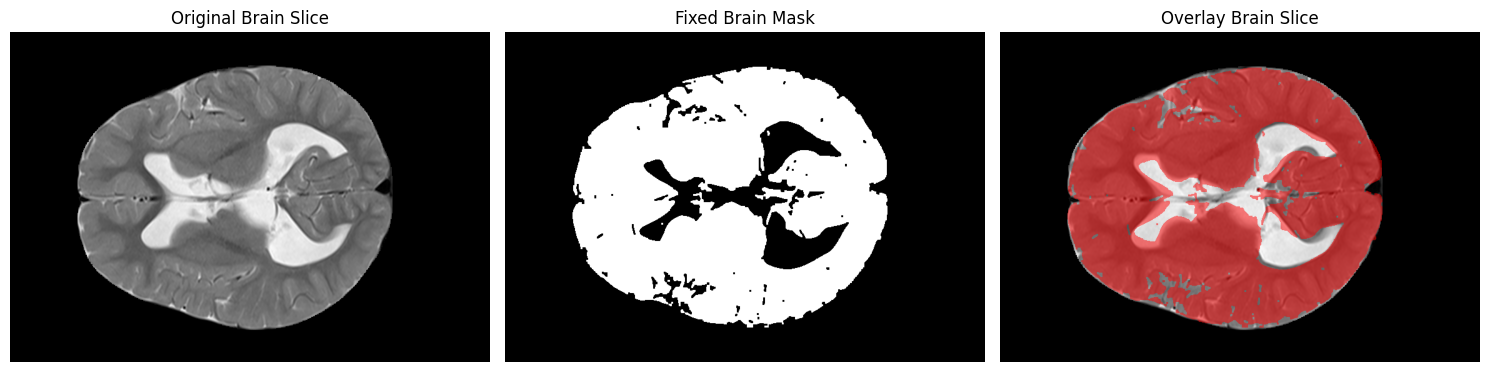

In [47]:
overlay_brain_slice = overlayMask(brain_slice, fixed_brain_mask)

# show original brain_slice and fixed_brain_mask
show_images_project2(
    images=[
        brain_slice, 
        fixed_brain_mask, 
        imageNormalization(overlay_brain_slice)
    ],
    titles=[
        'Original Brain Slice', 
        'Fixed Brain Mask', 
        'Overlay Brain Slice'
    ]
)

1. External Artifact

从叠加图来看，红色掩膜基本集中在脑区内部，脑外的大面积黑色背景没有被覆盖，这说明以上方法在去除脑外随机噪声方面是有效的。但在边界处有一些问题：

- 脑边界周围仍有少量多余的红色覆盖，没有做到绝对干净。
- 个别位置的掩膜稍微向外“鼓出”，把一些很薄的边界伪影也误认为是脑实质。


2. Internal structures

从叠加图看，脑内较大的低信号空腔（尤其是侧脑室）大体上仍然保持为未覆盖区域，这说明以上方法没有把脑室等真实孔洞简单地填满，保留了它们作为掩膜内部的“真阴性”区域。同时，也存在一些不足：

- 脑室周围的边界处理不够精细，边缘有些模糊。
- 一些更细小的脑内裂隙或沟样的暗区在处理中被当做缺陷修补掉了，导致损失了一部分的特征。


3. The integrity of the brain parenchyma boundary

从结果来看，脑实质主体已经形成了一个完整、连续的区域。原先边界上的断裂和毛刺得到了修复，整体连通性显著改善。但是边界过于平滑、局部外扩等常见问题依旧存在。并且在边界的细节方面，处理结果的精细度明显不足。